# Decision Tree Regression: Housing Price Prediction

## Project Overview
- **Algorithm**: Decision Tree Regressor
- **Problem**: Regression (predicting continuous price values)
- **Dataset**: California Housing Dataset (136,000+ samples, 8 features)
- **Focus**: Understanding Decision Tree Regressor vs Linear Regression

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

## 2. Load & Explore Data

In [2]:
# Load California housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Create DataFrame for better visualization
df = pd.DataFrame(X, columns=housing.feature_names)
df['Price'] = y

print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"\nFeatures: {list(housing.feature_names)}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset Info:
Shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [3]:
# Statistical summary
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        

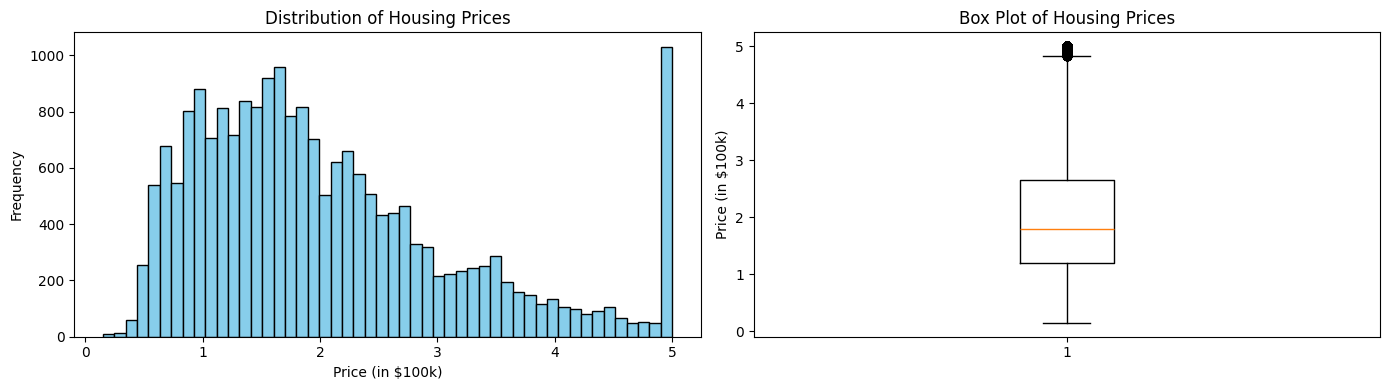

Price Range: $14999 - $500001
Mean Price: $206856


In [4]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Price'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Price (in $100k)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Housing Prices')

axes[1].boxplot(df['Price'])
axes[1].set_ylabel('Price (in $100k)')
axes[1].set_title('Box Plot of Housing Prices')

plt.tight_layout()
plt.show()

print(f"Price Range: ${y.min()*100000:.0f} - ${y.max()*100000:.0f}")
print(f"Mean Price: ${y.mean()*100000:.0f}")

## 3. Feature Correlation Analysis

Feature Correlation with Price:
Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


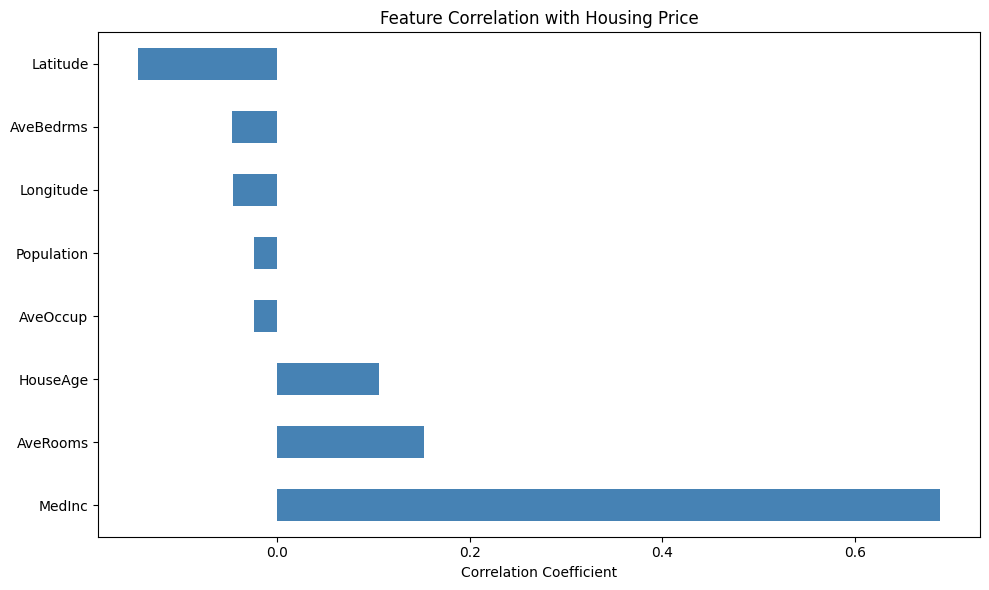

In [5]:
# Correlation with price
correlations = df.corr()['Price'].sort_values(ascending=False)
print("Feature Correlation with Price:")
print(correlations)

plt.figure(figsize=(10, 6))
correlations[1:].plot(kind='barh', color='steelblue')
plt.xlabel('Correlation Coefficient')
plt.title('Feature Correlation with Housing Price')
plt.tight_layout()
plt.show()

## 4. Train-Test Split

In [6]:
# Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set y range: ${y_train.min()*100000:.0f} - ${y_train.max()*100000:.0f}")

Training set size: 16512
Test set size: 4128
Training set y range: $14999 - $500001


## 5. Decision Tree Regressor

In [7]:
# Train Decision Tree Regressor
# Note: For regression, tree makes predictions by averaging target values at leaf nodes
dt_regressor = DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)
dt_regressor.fit(X_train, y_train)

print("Decision Tree Regressor trained!")
print(f"Tree depth: {dt_regressor.get_depth()}")
print(f"Number of leaves: {dt_regressor.get_n_leaves()}")

Decision Tree Regressor trained!
Tree depth: 10
Number of leaves: 587


In [8]:
# Make predictions
y_train_pred = dt_regressor.predict(X_train)
y_test_pred = dt_regressor.predict(X_test)

print("Predictions made!")
print(f"Sample predictions vs actual (first 5 test samples):")
for i in range(5):
    print(f"Actual: ${y_test[i]*100000:.0f}, Predicted: ${y_test_pred[i]*100000:.0f}")

Predictions made!
Sample predictions vs actual (first 5 test samples):
Actual: $47700, Predicted: $55230
Actual: $45800, Predicted: $72655
Actual: $500001, Predicted: $496858
Actual: $218600, Predicted: $225405
Actual: $278000, Predicted: $204551


## 6. Regression Performance Metrics

In [9]:
# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Decision Tree Regressor Performance:")
print("="*50)
print(f"\nR² Score:")
print(f"  Training: {train_r2:.4f}")
print(f"  Test:     {test_r2:.4f}")
print(f"\nRoot Mean Squared Error (in $100k):")
print(f"  Training: ${train_rmse:.4f}")
print(f"  Test:     ${test_rmse:.4f}")
print(f"\nMean Absolute Error (in $100k):")
print(f"  Training: ${train_mae:.4f}")
print(f"  Test:     ${test_mae:.4f}")

Decision Tree Regressor Performance:

R² Score:
  Training: 0.8274
  Test:     0.6818

Root Mean Squared Error (in $100k):
  Training: $0.4804
  Test:     $0.6457

Mean Absolute Error (in $100k):
  Training: $0.3301
  Test:     $0.4341


## 7. Prediction Analysis

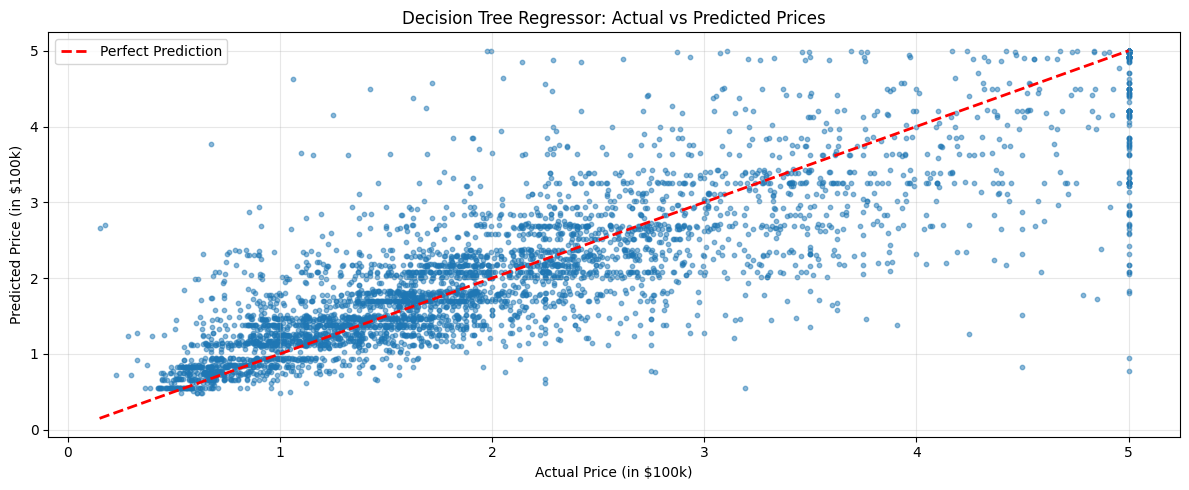

In [10]:
# Actual vs Predicted plot
plt.figure(figsize=(12, 5))

# Scatter plot
plt.scatter(y_test, y_test_pred, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (in $100k)')
plt.ylabel('Predicted Price (in $100k)')
plt.title('Decision Tree Regressor: Actual vs Predicted Prices')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

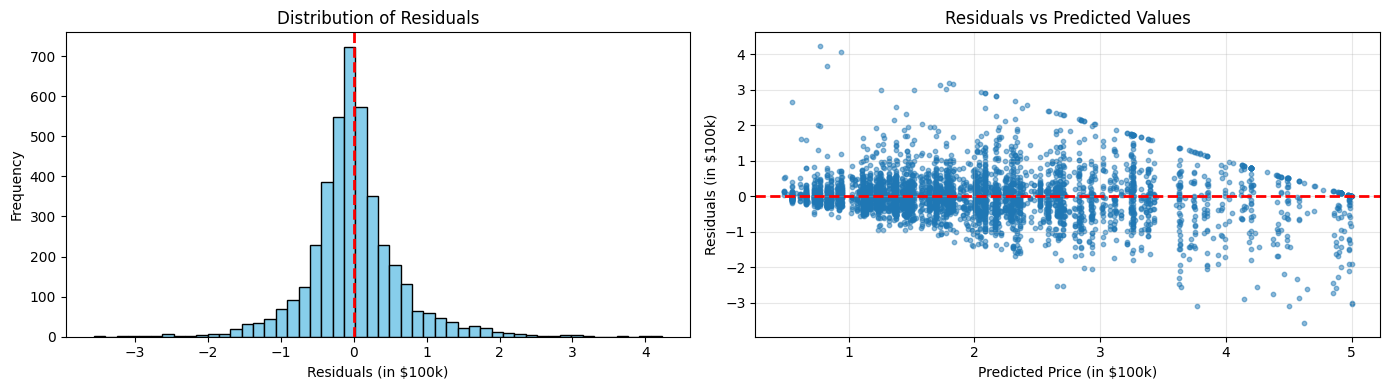

Mean Residual: -0.0026
Std Dev of Residuals: 0.6457


In [11]:
# Residuals plot
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals histogram
axes[0].hist(residuals, bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Residuals (in $100k)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals')
axes[0].axvline(0, color='red', linestyle='--', lw=2)

# Residuals vs Predicted
axes[1].scatter(y_test_pred, residuals, alpha=0.5, s=10)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price (in $100k)')
axes[1].set_ylabel('Residuals (in $100k)')
axes[1].set_title('Residuals vs Predicted Values')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Dev of Residuals: {residuals.std():.4f}")

## 8. Feature Importance

Feature Importance:
      Feature  Importance
0      MedInc    0.614010
5    AveOccup    0.130288
6    Latitude    0.079659
7   Longitude    0.067425
1    HouseAge    0.044206
2    AveRooms    0.037286
4  Population    0.014889
3   AveBedrms    0.012237


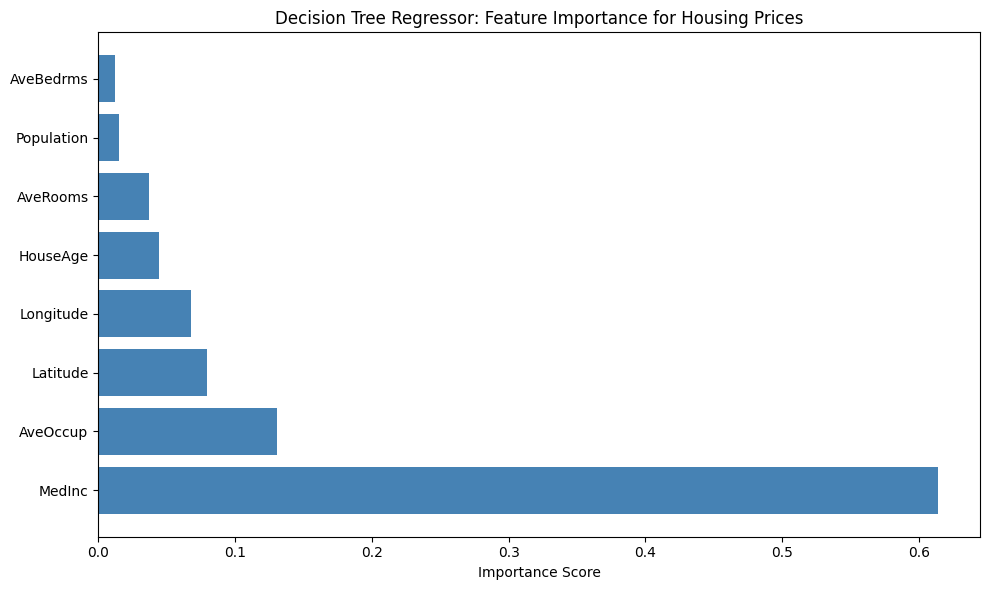

In [12]:
# Get feature importance
feature_importance = dt_regressor.feature_importances_

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Decision Tree Regressor: Feature Importance for Housing Prices')
plt.tight_layout()
plt.show()

## 9. Comparison: Decision Tree vs Linear Regression

Model Comparison (Test Set):
  Metric  Decision Tree Regressor  Linear Regression
R² Score                 0.681845           0.575788
    RMSE                 0.645688           0.745581
     MAE                 0.434129           0.533200


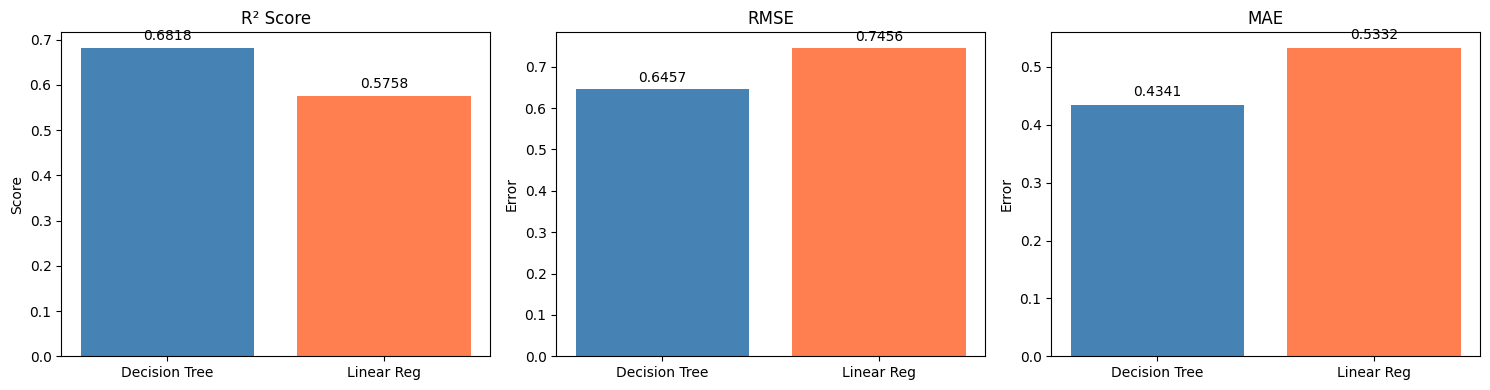

In [13]:
# Train Linear Regression for comparison
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_lr_pred = lr_model.predict(X_test)

# Calculate metrics
lr_r2 = r2_score(y_test, y_lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_lr_pred))
lr_mae = mean_absolute_error(y_test, y_lr_pred)

# Comparison
comparison_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE'],
    'Decision Tree Regressor': [test_r2, test_rmse, test_mae],
    'Linear Regression': [lr_r2, lr_rmse, lr_mae]
})

print("Model Comparison (Test Set):")
print("="*50)
print(comparison_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['R² Score', 'RMSE', 'MAE']
dt_vals = [test_r2, test_rmse, test_mae]
lr_vals = [lr_r2, lr_rmse, lr_mae]

for i, (ax, metric, dt_val, lr_val) in enumerate(zip(axes, metrics, dt_vals, lr_vals)):
    models = ['Decision Tree', 'Linear Reg']
    values = [dt_val, lr_val]
    colors = ['steelblue', 'coral']
    ax.bar(models, values, color=colors)
    ax.set_ylabel('Score' if metric == 'R² Score' else 'Error')
    ax.set_title(metric)
    for j, v in enumerate(values):
        ax.text(j, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 10. Summary

### Key Learnings:

1. **Decision Tree Regressor**:
   - Predicts continuous values (prices) by averaging target values at leaf nodes
   - Creates splits based on feature values to minimize prediction error
   - Can capture non-linear relationships in data

2. **Regression Evaluation Metrics**:
   - **R² Score**: Proportion of variance explained (higher is better, max 1.0)
   - **RMSE**: Root Mean Squared Error (penalizes large errors more)
   - **MAE**: Mean Absolute Error (average absolute error)

3. **Decision Tree vs Linear Regression**:
   - Decision trees can capture non-linear patterns
   - Linear regression assumes linear relationships
   - Trees are more interpretable (feature importance is clear)

4. **Feature Importance**:
   - Shows which features are most important for predictions
   - Helps identify key drivers of housing prices
   - In this case: Median Income and Location are crucial

### Classifier vs Regressor Comparison:
- **Classifier**: Predicts class labels (discrete categories like digits 0-9)
- **Regressor**: Predicts continuous numerical values (like prices)
- Both use the same tree structure but make predictions differently
  - Classifier: Returns majority class at leaf
  - Regressor: Returns average value at leaf